In [5]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt   
import seaborn as sns 

In [6]:
df = pd.read_csv('BHP.csv')

In [7]:
print("First 5 rows of the DataFrame:\n")
print(df.head())
print("\nData Types:\n")
print(df.dtypes)
print("\nShape of the DataFrame:\n")
print(df.shape)

First 5 rows of the DataFrame:

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  

Data Types:

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price

In [8]:
missingValues = df.isnull().sum()
percent = (missingValues/len(df)*100)
nullTables = pd.DataFrame ({
    "Missing Values": missingValues,
    "Percentage": percent
})
print(nullTables)
print("\nColumns with more than 20% mmissing values: \n")
print(nullTables[nullTables["Percentage"] > 20])

              Missing Values  Percentage
area_type                  0    0.000000
availability               0    0.000000
location                   1    0.007508
size                      16    0.120120
society                 5502   41.306306
total_sqft                 0    0.000000
bath                      73    0.548048
balcony                  609    4.572072
price                      0    0.000000

Columns with more than 20% mmissing values: 

         Missing Values  Percentage
society            5502   41.306306


In [10]:
for column in df.select_dtypes(include=np.number).columns:
    if(df[column].isnull().sum() / len(df) * 100 < 20):
        df[column].fillna(df[column].median())
print(df.isnull().sum())

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [11]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 529


In [13]:
df = df.drop_duplicates()
print("Duplicate rows after removal: ", df.duplicated().sum())
print("Rows Removed:", duplicates - df.duplicated().sum())

Duplicate rows after removal:  0
Rows Removed: 529


In [17]:
nullBefore = (df.isnull().sum() / df.shape[0]) * 100
nullAfter = (df.isnull().sum() / df.shape[0]) * 100

compare = pd.DataFrame({
    "Before Cleaning (%)": nullBefore,
    "After Cleaning (%)": nullAfter
})
print(compare)

              Before Cleaning (%)  After Cleaning (%)
area_type                0.000000            0.000000
availability             0.000000            0.000000
location                 0.007818            0.007818
size                     0.125088            0.125088
society                 41.654288           41.654288
total_sqft               0.000000            0.000000
bath                     0.570714            0.570714
balcony                  4.729888            4.729888
price                    0.000000            0.000000


In [30]:
print(df.dtypes)

area_type       category
availability      object
location          object
size              object
society           object
total_sqft       float64
bath             float64
balcony          float64
price            float64
dtype: object


In [ ]:
beforeConversion = df.memory_usage(deep=True).sum()
print(f"\nMemory usage before conversion:", beforeConversion, "bytes") 


Memory usage before conversion: 4789584 bytes


In [21]:
df["area_type"] = df["area_type"].astype("category")

In [22]:
df["total_sqft"].head(20)

0     1056
1     2600
2     1440
3     1521
4     1200
5     1170
6     2732
7     3300
8     1310
9     1020
10    1800
11    2785
12    1000
13    1100
14    2250
15    1175
16    1180
17    1540
18    2770
19    1100
Name: total_sqft, dtype: object

In [23]:
df["total_sqft"].unique()
for value in df["total_sqft"]:
    try:
        float(value)
    except ValueError:
        print(value)
        

2100 - 2850
3010 - 3410
2957 - 3450
3067 - 8156
1042 - 1105
1145 - 1340
1015 - 1540
1520 - 1740
34.46Sq. Meter
1195 - 1440
1200 - 2400
4125Perch
1120 - 1145
4400 - 6640
3090 - 5002
4400 - 6800
1160 - 1195
1000Sq. Meter
4000 - 5249
1115 - 1130
1100Sq. Yards
520 - 645
1000 - 1285
3606 - 5091
650 - 665
633 - 666
5.31Acres
30Acres
1445 - 1455
884 - 1116
850 - 1093
1440 - 1884
716Sq. Meter
547.34 - 827.31
580 - 650
3425 - 3435
1804 - 2273
3630 - 3800
660 - 670
4000 - 5249
1500Sq. Meter
620 - 933
142.61Sq. Meter
2695 - 2940
2000 - 5634
1574Sq. Yards
3450 - 3472
1250 - 1305
670 - 980
1005.03 - 1252.49
3630 - 3800
1004 - 1204
361.33Sq. Yards
645 - 936
2710 - 3360
2249.81 - 4112.19
3436 - 3643
2830 - 2882
596 - 804
1255 - 1863
1300 - 1405
1200 - 2400
1500 - 2400
117Sq. Yards
934 - 1437
980 - 1030
1564 - 1850
1446 - 1506
2249.81 - 4112.19
1070 - 1315
3040Sq. Meter
500Sq. Yards
2806 - 3019
613 - 648
1430 - 1630
704 - 730
1482 - 1846
2805 - 3565
3293 - 5314
1210 - 1477
3369 - 3464
1125 - 1500
167S

In [26]:
def convertsqft(x):
    try: 
        return float(x)
    except: 
        pass

    if "-" in str(x):
        nums = x.split("-")
        try:
            return (float(nums[0] + float(nums[1])) / 2)
        except: 
            return np.nan
        

In [29]:
df["total_sqft"] = df["total_sqft"].apply(convertsqft)
print(df.dtypes)
print(df["total_sqft"].isnull().sum())

area_type       category
availability      object
location          object
size              object
society           object
total_sqft       float64
bath             float64
balcony          float64
price            float64
dtype: object
246


In [31]:
memoryObj = df["area_type"].astype("object").memory_usage(deep=True)
memoryCategory = df["area_type"].astype("category").memory_usage(deep=True)

print("Memory as object:", memoryObj, "bytes")
print("Memory as category:", memoryCategory, "bytes")
print("Memory saved:", memoryObj - memoryCategory, "bytes")

Memory as object: 949933 bytes
Memory as category: 115543 bytes
Memory saved: 834390 bytes


In [32]:
df.describe()

,total_sqft,bath,balcony,price
count,12545.000000,12718.000000,12186.000000,12791.000000
mean,1564.984242,2.708602,1.582308,114.317646
std,1260.270912,1.357764,0.822536,151.480310
min,1.000000,1.000000,0.000000,8.000000
25%,1100.000000,2.000000,1.000000,50.000000
50%,1280.000000,2.000000,2.000000,73.000000
75%,1685.000000,3.000000,2.000000,121.000000
max,52272.000000,40.000000,3.000000,3600.000000


In [35]:
print(df.skew(numeric_only=True))

skewness = df.skew(numeric_only=True)
print(skewness)
Skeweded = skewness.abs().idxmax()
print("\nMost skewed column:", Skeweded)
print("Skewness value:", skewness[Skeweded])

total_sqft    15.288177
bath           4.205467
balcony        0.010080
price          7.954354
dtype: float64
total_sqft    15.288177
bath           4.205467
balcony        0.010080
price          7.954354
dtype: float64

Most skewed column: total_sqft
Skewness value: 15.288176659028517


In [36]:
#Outlier detection
columns = ["price", "total_sqft"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lowerBound = Q1 - 1.5 * IQR
    upperBound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lowerBound) | (df[col] > upperBound)]
    print("="*40)
    print("Column:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lowerBound)
    print("Upper Bound:", upperBound)
    print("Number of outliers:", len(outliers))

    

Column: price
Q1: 50.0
Q3: 121.0
IQR: 71.0
Lower Bound: -56.5
Upper Bound: 227.5
Number of outliers: 1257
Column: total_sqft
Q1: 1100.0
Q3: 1685.0
IQR: 585.0
Lower Bound: 222.5
Upper Bound: 2562.5
Number of outliers: 1092


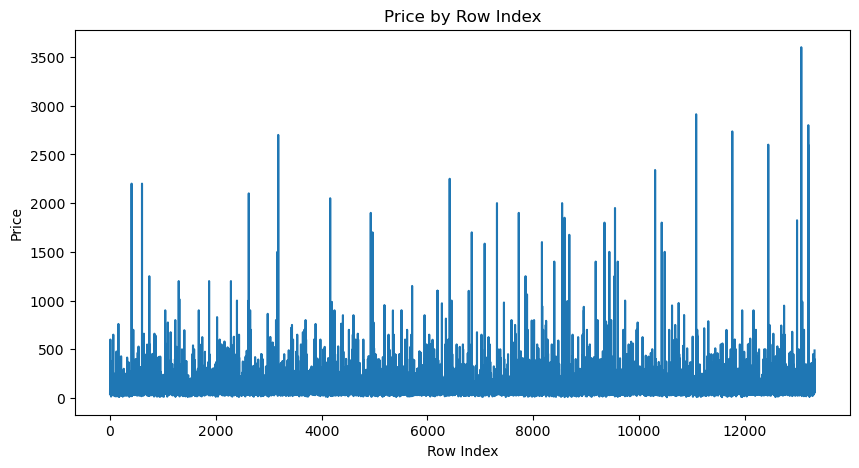

/var/folders/mp/mcv_m12954x3_vkk7dp3dxhr0000gn/T/ipykernel_1195/2713103461.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("area_type") ["price"].mean().plot(kind="bar")


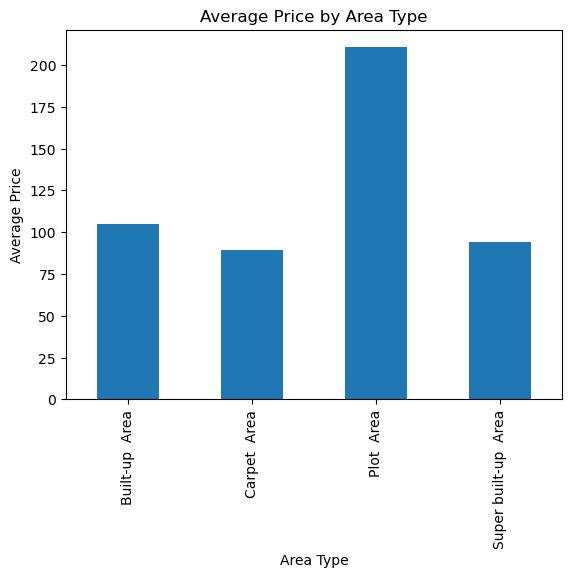

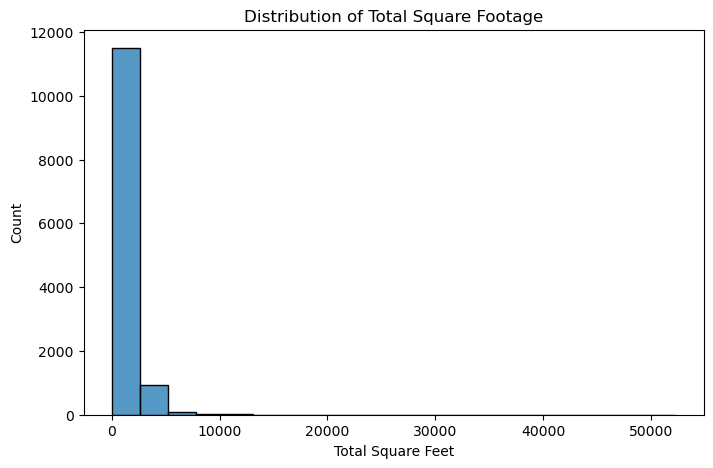

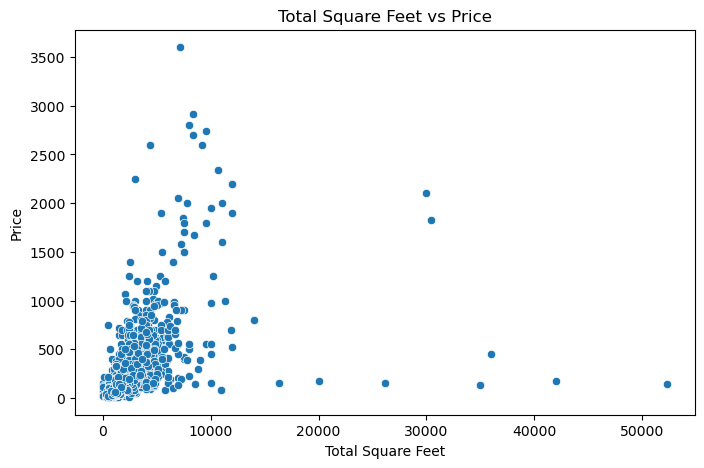

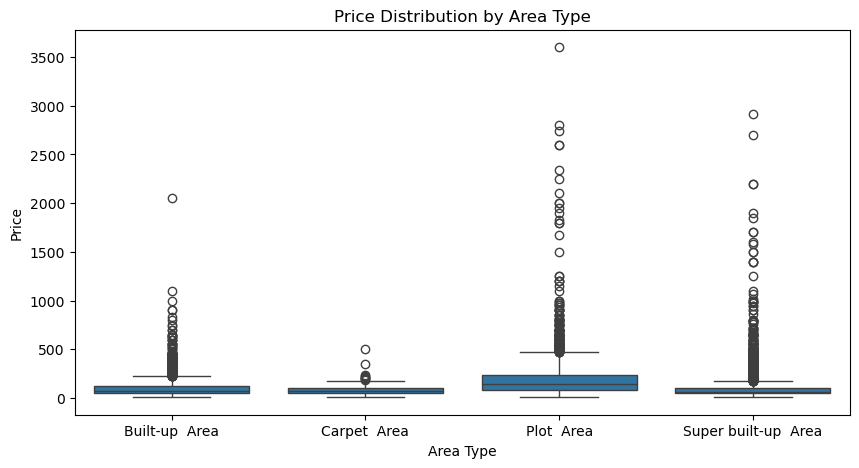

In [40]:
#Visualization
#lineplot
plt.figure(figsize=(10, 5))
plt.plot(df["price"])
plt.title("Price by Row Index")
plt.xlabel("Row Index")
plt.ylabel("Price")
plt.show()

#barchart
df.groupby("area_type") ["price"].mean().plot(kind="bar")

plt.title("Average Price by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Average Price")
plt.show()

#histogram
plt.figure(figsize=(8, 5))
sns.histplot(df["total_sqft"], bins=20)

plt.title("Distribution of Total Square Footage")
plt.xlabel("Total Square Feet")
plt.ylabel("Count")
plt.show()

#scatterPlot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="total_sqft", y="price")
plt.title("Total Square Feet vs Price")
plt.xlabel("Total Square Feet")
plt.ylabel("Price")
plt.show()

#boxPlot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="area_type", y="price")
plt.title("Price Distribution by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Price")
plt.show()


            total_sqft      bath   balcony     price
total_sqft    1.000000  0.383608  0.152514  0.571339
bath          0.383608  1.000000  0.200387  0.453099
balcony       0.152514  0.200387  1.000000  0.118645
price         0.571339  0.453099  0.118645  1.000000


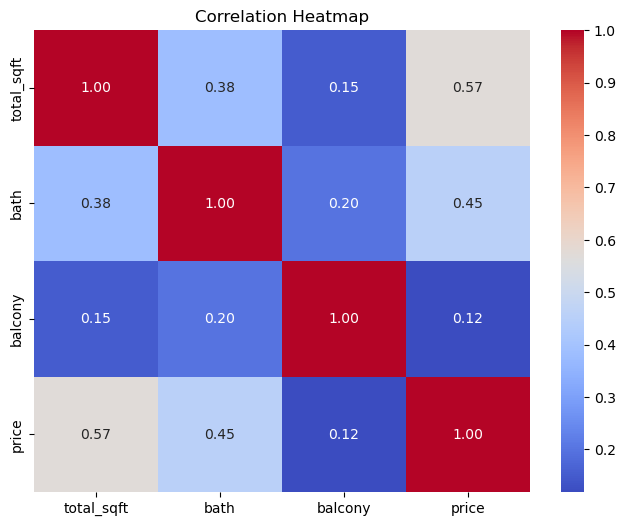

In [41]:
#Correlation heat map
import matplotlib.pyplot as plt
import seaborn as sns

correlationMatrix = df.corr(numeric_only=True)
print(correlationMatrix)
plt.figure(figsize=(8,6))
sns.heatmap(correlationMatrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [42]:
correlationMatrix = correlationMatrix.abs()
import numpy as np
np.fill_diagonal(correlationMatrix.values, 0)
highestCorrelation = correlationMatrix.unstack().idxmax()
print("\nHighest correlation pair:", highestCorrelation)  
print("Correlation:", correlationMatrix.loc[highestCorrelation])  



Highest correlation pair: ('total_sqft', 'price')
Correlation: 0.5713386618427396


In [43]:
#Imputation strategy comparison
cols = ["total_sqft", "price"]
for col in cols:
    print("="*40)
    print(col)

    print("Mean :", df[col].mean())
    print("Median :", df[col].median())

for col in cols:
    df[col] = df[col].fillna(df[col].median())
print(df[cols].isnull().sum())

total_sqft
Mean : 1564.9842423276207
Median : 1280.0
price
Mean : 114.31764639199436
Median : 73.0
total_sqft    0
price         0
dtype: int64


In [45]:
#Spearman rank correlation
pearson = df.corr(numeric_only=True)
spearman = df.corr(method='spearman', numeric_only=True)
print("\nPearson Correlation:\n", pearson)
print("\nSpearman Correlation:\n", spearman)
print()
print("Spearman Correlation")
print(spearman)

difference = (spearman - pearson).abs()
print(difference)
diff = difference.unstack()
diff = diff.sort_values(ascending=False)
diff = diff[diff.index.get_level_values(0) != diff.index.get_level_values(1)]
print(diff.head(6))


Pearson Correlation:
             total_sqft      bath   balcony     price
total_sqft    1.000000  0.379082  0.153637  0.568408
bath          0.379082  1.000000  0.200387  0.453099
balcony       0.153637  0.200387  1.000000  0.118645
price         0.568408  0.453099  0.118645  1.000000

Spearman Correlation:
             total_sqft      bath   balcony     price
total_sqft    1.000000  0.628337  0.306970  0.722146
bath          0.628337  1.000000  0.290266  0.716358
balcony       0.306970  0.290266  1.000000  0.205688
price         0.722146  0.716358  0.205688  1.000000

Spearman Correlation
            total_sqft      bath   balcony     price
total_sqft    1.000000  0.628337  0.306970  0.722146
bath          0.628337  1.000000  0.290266  0.716358
balcony       0.306970  0.290266  1.000000  0.205688
price         0.722146  0.716358  0.205688  1.000000
            total_sqft      bath   balcony     price
total_sqft    0.000000  0.249255  0.153333  0.153738
bath          0.249255  0.0000

In [49]:
#Grouped aggregation
group = df.groupby("area_type")["price"].agg(["mean", "std", "count"])
print(group)
print("Highest Mean Group:")
print(group["mean"].idxmax())
print()
print("Highest Std Group:")
print(group["std"].idxmax())

#ratio
highest = group["mean"].max()
lowest = group["mean"].min()
ratio = highest / lowest
print("Ratio:", ratio)

                            mean         std  count
area_type                                          
Built-up  Area        104.797763  109.572191   2398
Carpet  Area           89.502356   73.446012     87
Plot  Area            210.520543  254.944834   1989
Super built-up  Area   94.315248  116.579057   8317
Highest Mean Group:
Plot  Area

Highest Std Group:
Plot  Area
Ratio: 2.3521229120428995


/var/folders/mp/mcv_m12954x3_vkk7dp3dxhr0000gn/T/ipykernel_1195/1850302830.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby("area_type")["price"].agg(["mean", "std", "count"])


In [50]:
#Save the clean dataset
df.to_csv("BHP_cleaned.csv", index=False)